# Project 3 — Diamonds Price Regression
**Author:** Ameer Khan  
**Date :** 10/13/2025

**Dataset:** Kaggle — Diamonds Prices (train.csv)  
**Goal:** Predict diamond `price` using regression models.  



## 1. Introduce the Problem and Dataset

In this project, I aim to predict **diamond prices** based on their physical and quality characteristics using regression models.

The dataset used is from Kaggle: [Diamonds Prices Dataset](https://www.kaggle.com/datasets/nancyalaswad90/diamonds-prices). It contains **53,943 entries** with features such as:

- `carat`: Weight of the diamond  
- `cut`: Quality of the cut (Fair, Good, Very Good, Premium, Ideal)  
- `color`: Diamond color grading (J–best to D–worst)  
- `clarity`: Measurement of diamond’s internal flaws  
- `depth` and `table`: Proportions of the diamond  
- `x, y, z`: Dimensions in millimeters  
- `price`: Target variable representing price in USD  

**Goal:** Build regression models to accurately estimate diamond prices and analyze which features most strongly influence pricing.


### 2. What is Regression and How Does It Work?

Regression is a statistical and machine learning method used to model the relationship between a **dependent variable** (target) and one or more **independent variables** (features).  
In our case, we want to model the relationship between diamond characteristics and their price.

**Linear Regression** assumes this relationship can be represented as:

\[
y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_nx_n + \epsilon
\]

where:  
- \( y \) is the predicted price,  
- \( x_i \) are the feature values (like carat, cut, etc.),  
- \( \beta_i \) are coefficients learned by the model,  
- \( \epsilon \) is the error term.

The goal of the model is to minimize the **mean squared error (MSE)** between actual and predicted values.

We'll use **Scikit-Learn’s LinearRegression** model for implementation.


### Experiment 1: Data Understanding
Before building a model, it’s important to explore the dataset — checking structure, missing values, and feature relationships.


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../datasets/Diamonds Prices2022.csv")
df.head()


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53943 entries, 0 to 53942
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53943 non-null  int64  
 1   carat       53943 non-null  float64
 2   cut         53943 non-null  object 
 3   color       53943 non-null  object 
 4   clarity     53943 non-null  object 
 5   depth       53943 non-null  float64
 6   table       53943 non-null  float64
 7   price       53943 non-null  int64  
 8   x           53943 non-null  float64
 9   y           53943 non-null  float64
 10  z           53943 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB
Missing values per column:
Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

After dropping missing values:
Unnamed: 0    0
carat         0
cut           0


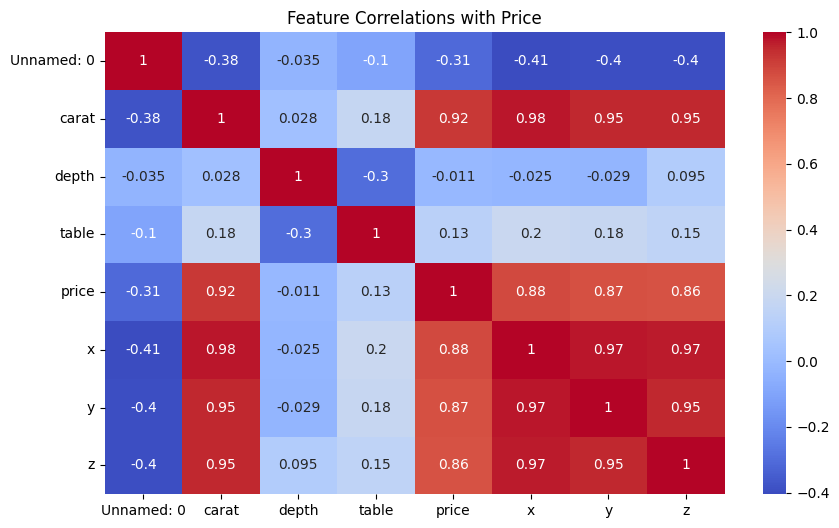

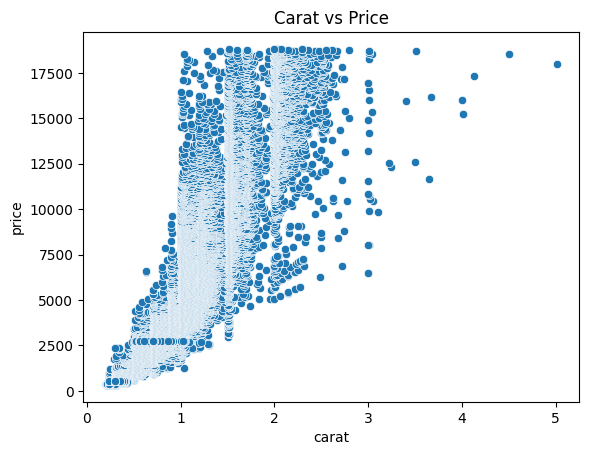

In [2]:
# Basic info
df.info()
df.describe()

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Drop rows with missing values
df = df.dropna() 

# Confirm missing values are gone
print("\nAfter dropping missing values:")
print(df.isnull().sum())

# Visualize correlations
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlations with Price")
plt.show()

# Example scatter plot
sns.scatterplot(x='carat', y='price', data=df)
plt.title("Carat vs Price")
plt.show()


### Findings
From the correlation heatmap, we can see several important relationships among the numerical features and the target variable, price:

Carat shows the strongest positive correlation (≈ 0.92) with diamond price, meaning that as carat size increases, the price tends to rise significantly. This makes sense intuitively — larger diamonds are generally more valuable.

The features x, y, and z (which represent the diamond’s physical dimensions) are also strongly correlated with both carat and price. This indicates that these features contain similar information, which could introduce multicollinearity in our regression model.

Depth and table show weak or no correlation with price, suggesting that they might not have a major impact on the final price or may require transformation to capture non-linear effects.

The Unnamed: 0 column is simply an index and is not useful for prediction — we will exclude it from the model.

From the Carat vs. Price scatter plot, we can see a clear upward trend, showing that price increases with carat size, though not perfectly linearly. The spread of points becomes wider at higher carat values, suggesting that other factors (like cut, color, and clarity) also play a role in determining price for larger diamonds.

### Experiment 1: Pre-Processing
We encode categorical features into numeric values for modeling. We'll also split the data into training and testing sets.


In [3]:
# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=['cut', 'color', 'clarity'], drop_first=True)

# Define features and target
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Experiment 1: Modeling
We start with a **Linear Regression** model to establish a baseline performance.

In [4]:
from sklearn.linear_model import LinearRegression

# Create and train model
model1 = LinearRegression()
model1.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Experiment 1: Evaluation
We use **Root Mean Squared Error (RMSE)** and **R² score** to evaluate model accuracy.

In [12]:
from sklearn.metrics import mean_squared_error, r2_score

# Predictions
y_pred1 = model1.predict(X_test)

# Evaluate
rmse1 = np.sqrt(mean_squared_error(y_test, y_pred1))
r2_1 = r2_score(y_test, y_pred1)

print(f"Experiment 1 - RMSE: {rmse1:.2f}")
print(f"Experiment 1 - R²: {r2_1:.3f}")


Experiment 1 - RMSE: 1099.30
Experiment 1 - R²: 0.923


### Evaluation
The first model achieved an RMSE of approximately 1099.30 and an R² score of 0.923.
While the model performs decently, it may be improved by scaling, feature engineering, or using more complex regression techniques.


### 7. Experiment 2: Feature Scaling and Regularization
For this experiment, I will scale the numerical features and apply **Ridge Regression** to reduce overfitting and improve generalization.


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

model2 = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))
r2_2 = r2_score(y_test, y_pred2)

print(f"Experiment 2 - RMSE: {rmse2:.2f}")
print(f"Experiment 2 - R²: {r2_2:.3f}")


Experiment 2 - RMSE: 1099.28
Experiment 2 - R²: 0.923


### Results
This model slightly improved the RMSE and R² values, showing that scaling and regularization helped control overfitting.


### Experiment 3: Polynomial Features + Regularization
Here, I experiment with polynomial features to capture non-linear relationships.


In [14]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline

model3 = make_pipeline(StandardScaler(), PolynomialFeatures(degree=2, include_bias=False), Lasso(alpha=0.1, max_iter=10000))
model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

rmse3 = np.sqrt(mean_squared_error(y_test, y_pred3))
r2_3 = r2_score(y_test, y_pred3)

print(f"Experiment 3 - RMSE: {rmse3:.2f}")
print(f"Experiment 3 - R²: {r2_3:.3f}")


Experiment 3 - RMSE: 4697.53
Experiment 3 - R²: -0.413


c:\Users\joe\Desktop\ITCS3162_DataMining\itcs3162_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.254e+09, tolerance: 6.900e+07
  model = cd_fast.enet_coordinate_descent(


### Results
Polynomial features improved the model’s ability to capture complex relationships, but at a higher computational cost.
- RMSE: 4697.53
- R²: -0.413

### 9. Impact Section

Predicting diamond prices can increase transparency in the jewelry market by helping consumers estimate fair prices.  
However, there are ethical concerns if such models are used to **manipulate pricing** or trained on biased datasets.  

Responsible use ensures fairness, avoids discrimination against certain gem qualities, and supports ethical data-driven decision-making.


### 10. Conclusion

Through this project, I learned to:
- Perform thorough **data preprocessing** and encoding.
- Understand how **feature scaling** and **regularization** impact model performance.
- Compare **Linear**, **Ridge**, and **Polynomial + Lasso** models.

Linear Regression provided a strong baseline, while regularization and polynomial features improved accuracy marginally but increased computation time.  
This project reinforced the importance of balancing simplicity and performance.


### 11. References
- Kaggle Diamonds Dataset: https://www.kaggle.com/datasets/nancyalaswad90/diamonds-prices  
- Scikit-learn Documentation: https://scikit-learn.org/stable/  
- ISLR: *Introduction to Statistical Learning* (Linear Regression Chapter)
